<a href="https://colab.research.google.com/github/rahatunalam/Superstore-Sales-Analysis/blob/main/Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/AI_practice/Datasets/Sample_Superstore.csv', encoding='latin-1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
print(df.columns)
df.shape

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')


(9994, 21)

In [ ]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)

Shape: (9994, 21)

Missing values:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Data types:
 Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [ ]:
# Fix date columns and postal code before EDA
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df['Postal Code'] = df['Postal Code'].astype(str)

print("Fixed! Order Date type:", df['Order Date'].dtype)

Fixed! Order Date type: datetime64[ns]


Min, max, mean and spread of every numerical column

In [ ]:
# Basic statistical summary
df[['Sales', 'Profit', 'Quantity', 'Discount']].describe().round(2)

,Sales,Profit,Quantity,Discount
count,9994.00,9994.00,9994.00,9994.00
mean,229.86,28.66,3.79,0.16
std,623.25,234.26,2.23,0.21
min,0.44,-6599.98,1.00,0.00
25%,17.28,1.73,2.00,0.00
50%,54.49,8.67,3.00,0.20
75%,209.94,29.36,5.00,0.20
max,22638.48,8399.98,14.00,0.80


**Sales** — the average order is 229  but  the  median (50%) is only 54. That huge gap means a small number of very large orders are pulling the average up. Max sale is $22,638! This is called a right-skewed distribution — very common in retail data.

**Profit** — this is the most interesting one. The minimum profit is -$6,599. Negative profit means the store is losing money on some orders, likely due to heavy discounting. You'll investigate this in EDA.

**Discount** — goes up to 80% off. That's aggressive. You'll later find a strong link between high discounts and negative profit.

**Quantity** — median is 3 units per order, max is 14. Pretty consistent, nothing alarming.

##EDA(Explanatory Data Analysis)

####Sales & profit by Category:

In [ ]:
category_summary = df.groupby('Category')[['Sales','Profit']].sum().round(2)
category_summary['Profit Margin %'] = ((category_summary['Profit'] / category_summary['Sales']) * 100).round(2)
print(category_summary.sort_values('Sales', ascending=False))

                     Sales     Profit  Profit Margin %
Category                                              
Technology       836154.03  145454.95            17.40
Furniture        741999.80   18451.27             2.49
Office Supplies  719047.03  122490.80            17.04


**Category findings:**
Technology leads in sales (836K) and has the best profit margin at 17.4%. Furniture is dangerous — it's the 2nd highest in sales ($742K) but only 2.49% profit margin. Almost breaking even. Office Supplies punches above its weight with 17% margin despite lower sales.

####Sales by Region

In [ ]:
region_summary = df.groupby('Region')[['Sales','Profit']].sum().round(2)
region_summary['Profit Margin %'] = ((region_summary['Profit'] / region_summary['Sales']) * 100).round(2)
print(region_summary.sort_values('Sales', ascending=False))

             Sales     Profit  Profit Margin %
Region                                        
West     725457.82  108418.45            14.94
East     678781.24   91522.78            13.48
Central  501239.89   39706.36             7.92
South    391721.90   46749.43            11.93


Region findings:
West is the star — highest sales AND highest profit margin (14.94%). Central region is the problem — decent sales ($501K) but only 7.92% margin. Something is dragging it down, likely heavy discounting.

####Monthly sales trend

In [ ]:
df['Month-Year'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('Month-Year')['Sales'].sum().round(2)
print(monthly_sales.tail(12))

Month-Year
2017-01     43971.37
2017-02     20301.13
2017-03     58872.35
2017-04     36521.54
2017-05     44261.11
2017-06     52981.73
2017-07     45264.42
2017-08     63120.89
2017-09     87866.65
2017-10     77776.92
2017-11    118447.82
2017-12     83829.32
Freq: M, Name: Sales, dtype: float64


Monthly trend:
November 2017 is the peak month at 118K — that's the holiday effect. February is the lowest at $20K. Sales clearly have strong seasonality which is a great insight for your dashboard.

####Discount impact on profit

In [ ]:
discount_profit = df.groupby('Discount')[['Sales','Profit']].mean().round(2)
print(discount_profit)

           Sales  Profit
Discount                
0.00      226.74   66.90
0.10      578.40   96.06
0.15      529.97   27.29
0.20      209.08   24.70
0.30      454.74  -45.68
0.32      536.79  -88.56
0.40      565.13 -111.93
0.45      498.63 -226.65
0.50      892.71 -310.70
0.60       48.15  -43.08
0.70       97.18  -95.87
0.80       56.55 -101.80


Discount vs Profit — the smoking gun:
At 0% discount, average profit is 66.90. The moment discount hits 30%, profit turns negative at 45. At 50% discount, average profit is 310 per order. The business is literally losing over 300 on every heavily discounted order. This single insight is worth highlighting in your resume as a key business finding.

####Top 10 loss-making products

In [ ]:
print("\nTop 10 loss-making products:")
loss = df[df['Profit'] < 0].groupby('Product Name')['Profit'].sum().round(2)
print(loss.sort_values().head(10))


Top 10 loss-making products:
Product Name
Cubify CubeX 3D Printer Double Head Print                                     -9239.97
GBC DocuBind P400 Electric Binding System                                     -6859.39
Lexmark MX611dhe Monochrome Laser Printer                                     -5269.97
GBC Ibimaster 500 Manual ProClick Binding System                              -5098.57
GBC DocuBind TL300 Electric Binding System                                    -4162.03
Cubify CubeX 3D Printer Triple Head Print                                     -3839.99
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind   -3431.67
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases                      -3107.53
Ibico EPK-21 Electric Binding System                                          -2929.48
Bush Advantage Collection Racetrack Conference Table                          -2545.26
Name: Profit, dtype: float64


Loss-making products:
The Cubify CubeX 3D Printer alone has lost 9,239 — that's the single worst product. Notice that 3D printers and binding machines dominate this list, all from the Technology and Office Supplies categories being sold at deep discounts.

##Visualization

In [ ]:
# Set visual style once for all charts
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

##### Chart 1 — Sales & Profit by Category

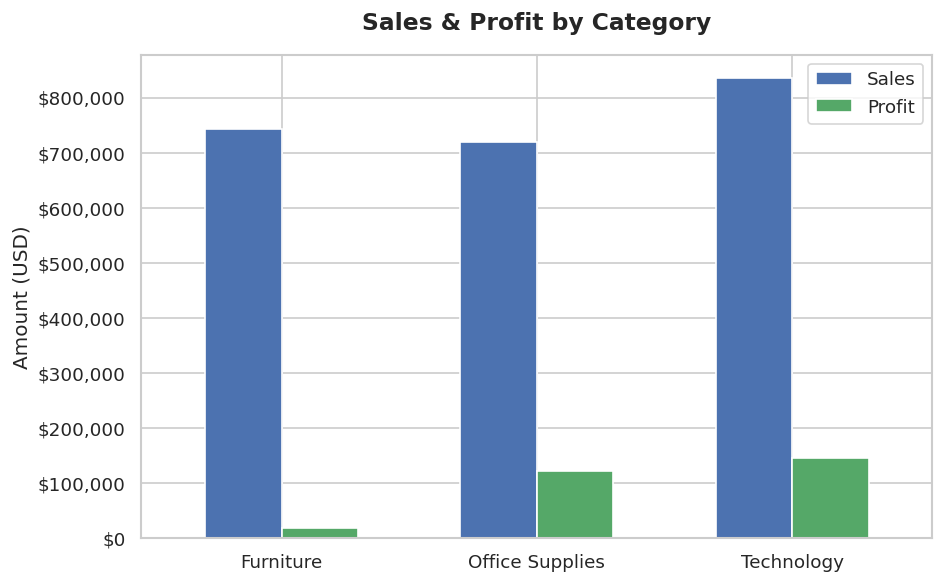

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
category_summary[['Sales','Profit']].plot(
    kind='bar', ax=ax, color=['#4C72B0','#55A868'],
    edgecolor='white', width=0.6
)
ax.set_title('Sales & Profit by Category', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('Amount (USD)')
ax.set_xticklabels(category_summary.index, rotation=0)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}')
)
plt.tight_layout()
plt.savefig('chart1_category.png', bbox_inches='tight')
plt.show()

#### Profit Margin by Region:

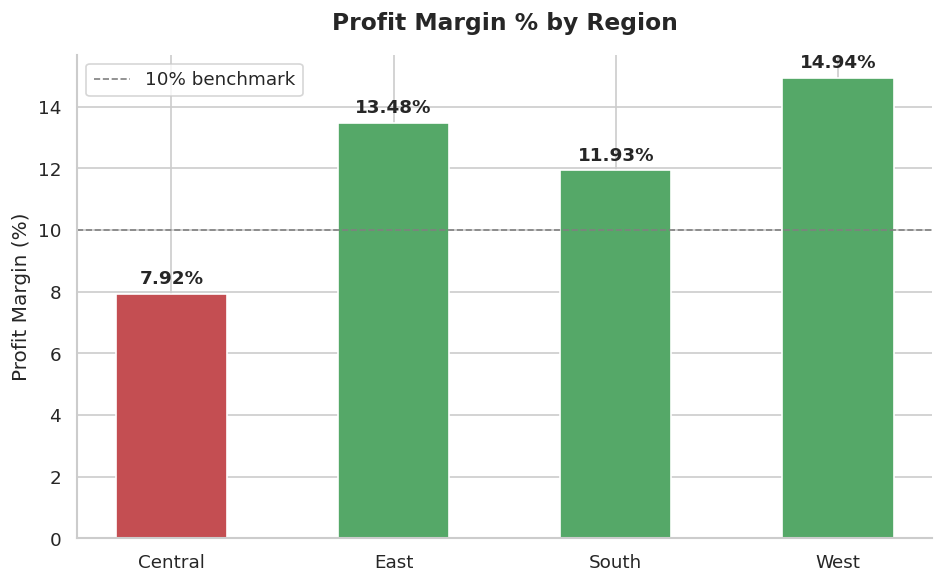

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#55A868' if x > 10 else '#C44E52' for x in region_summary['Profit Margin %']]
bars = ax.bar(region_summary.index, region_summary['Profit Margin %'],
              color=colors, edgecolor='white', width=0.5)
ax.axhline(y=10, color='gray', linestyle='--', linewidth=1, label='10% benchmark')
for bar, val in zip(bars, region_summary['Profit Margin %']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Profit Margin % by Region', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Profit Margin (%)')
ax.set_xlabel('')
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('chart2_region.png', bbox_inches='tight')
plt.show()

#### Monthly Sales Trend:

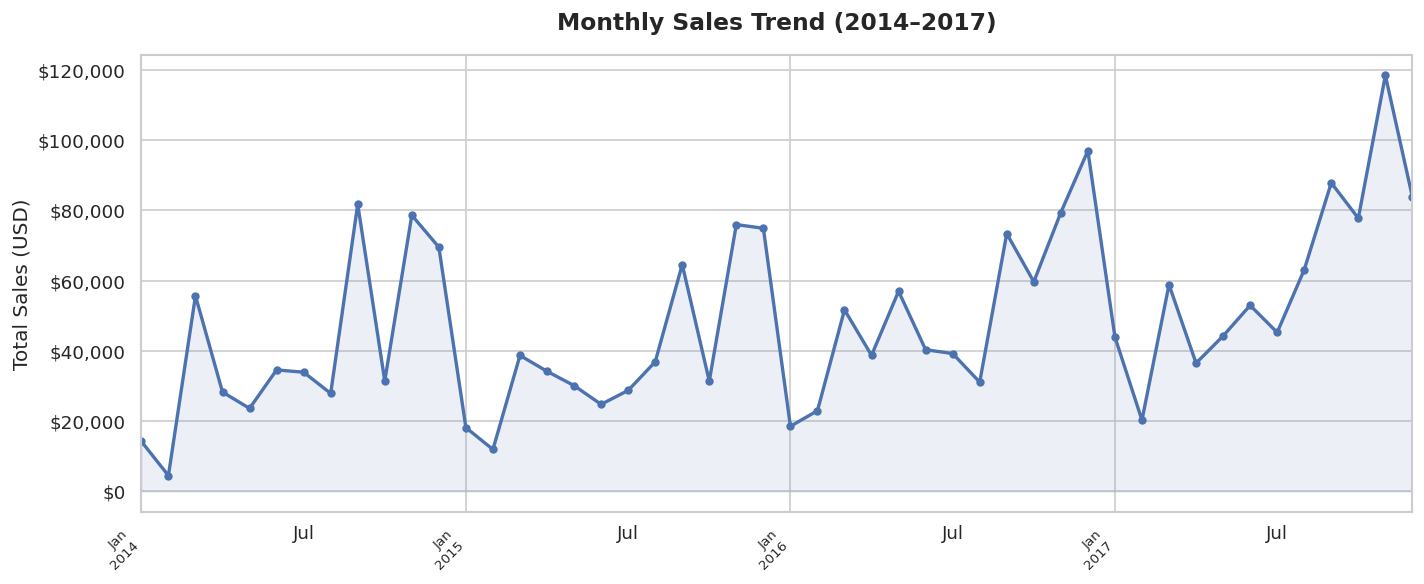

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
monthly_sales.plot(ax=ax, color='#4C72B0', linewidth=2, marker='o', markersize=4)
ax.set_title('Monthly Sales Trend (2014–2017)', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Total Sales (USD)')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.fill_between(monthly_sales.index.astype(str), monthly_sales.values, alpha=0.1, color='#4C72B0')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('chart3_monthly_trend.png', bbox_inches='tight')
plt.show()

#### Discount vs Profit scatter:

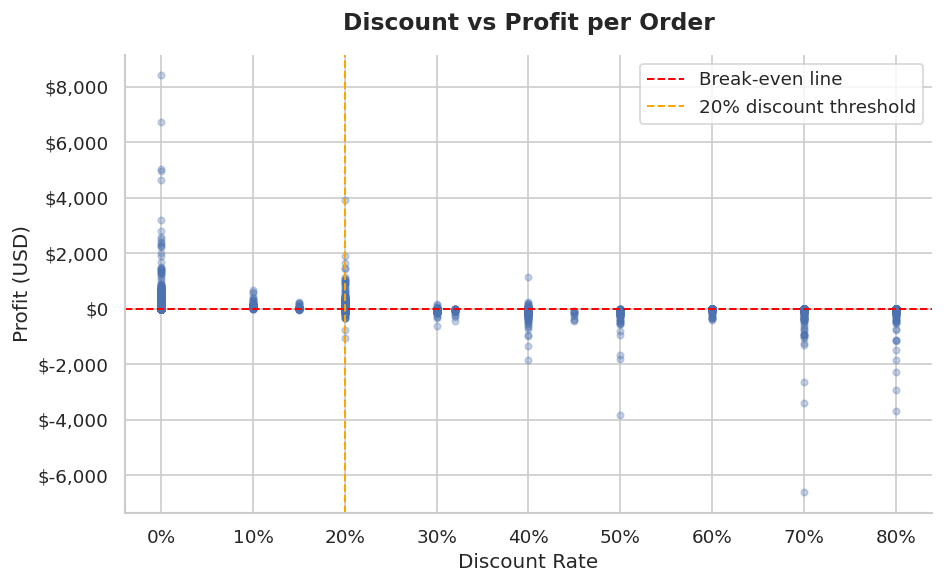

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['Discount'], df['Profit'], alpha=0.3, color='#4C72B0', s=15)
ax.axhline(y=0, color='red', linestyle='--', linewidth=1.2, label='Break-even line')
ax.axvline(x=0.2, color='orange', linestyle='--', linewidth=1.2, label='20% discount threshold')
ax.set_title('Discount vs Profit per Order', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Discount Rate')
ax.set_ylabel('Profit (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x*100)}%'))
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('chart4_discount_profit.png', bbox_inches='tight')
plt.show()

In [ ]:
# Export cleaned data for Power BI
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month_Name'] = df['Order Date'].dt.strftime('%b')

df.to_csv('/content/drive/MyDrive/AI_practice/Datasets/Superstore_cleaned.csv', index=False)
print("File saved! Rows:", len(df), "| Columns:", len(df.columns))

File saved! Rows: 9994 | Columns: 25
